# Table S2. Retrospective selection of cluster marker-summary parameters

This notebook is the clean-clone reconstruction for Supplementary Table S2. It:

1. verifies the byte-level identity of the versioned source CSV;
2. validates the method order, parameter grids, and selected values;
3. derives the candidate-grid cardinalities; and
4. writes regenerated PNG and PDF files under `outputs/source_rebuilt/table_s02/`.

The source CSV is the authoritative small table input. The tracked publication preview is a separate, source-traced review artifact and is not used by this reconstruction.

In [1]:
from __future__ import annotations

from decimal import Decimal
from hashlib import sha256
from math import prod
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

EXPECTED_SOURCE_SHA256 = "e91af5dfc7ef27687aa8b07acbc74b86f9c2f119228dc1d2db20034f5ec671f4"
SOURCE_RELATIVE_PATH = Path("data/tables/supplementary_table_s02_marker_summary_optimization.csv")


def find_repository_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / SOURCE_RELATIVE_PATH).is_file():
            return candidate
    raise FileNotFoundError(
        f"Could not find {SOURCE_RELATIVE_PATH} from {start} or any parent directory."
    )


REPOSITORY_ROOT = find_repository_root()
SOURCE_PATH = REPOSITORY_ROOT / SOURCE_RELATIVE_PATH
OUTPUT_DIR = REPOSITORY_ROOT / "outputs/source_rebuilt/table_s02"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

source_digest = sha256(SOURCE_PATH.read_bytes()).hexdigest()
if source_digest != EXPECTED_SOURCE_SHA256:
    raise ValueError(
        "Table S2 source digest mismatch: "
        f"expected {EXPECTED_SOURCE_SHA256}, observed {source_digest}"
    )

print(f"Verified source: {SOURCE_RELATIVE_PATH}")
print(f"SHA-256: {source_digest}")
print(f"Generated files: {OUTPUT_DIR.relative_to(REPOSITORY_ROOT)}/")

Verified source: data/tables/supplementary_table_s02_marker_summary_optimization.csv
SHA-256: e91af5dfc7ef27687aa8b07acbc74b86f9c2f119228dc1d2db20034f5ec671f4
Generated files: outputs/source_rebuilt/table_s02/


In [2]:
EXPECTED_COLUMNS = [
    "Method",
    "Fine-grid expression threshold",
    "Fine-grid fraction threshold",
    "Fine-grid mean-expression threshold",
    "Fine-grid maximum markers",
    "Fine-grid fallback minimum markers",
    "Selected expression threshold",
    "Selected fraction threshold",
    "Selected mean-expression threshold",
    "Selected maximum markers",
    "Selected fallback minimum markers",
]
EXPECTED_METHODS = ["FlowSOM", "Leiden", "SpatialSort", "PIXIE-style adaptation"]
EXPECTED_COMBINATIONS = {
    "FlowSOM": 1_152,
    "Leiden": 960,
    "SpatialSort": 960,
    "PIXIE-style adaptation": 960,
}

source = pd.read_csv(SOURCE_PATH, dtype=str, keep_default_na=False)
if source.columns.tolist() != EXPECTED_COLUMNS:
    raise ValueError(f"Unexpected Table S2 columns: {source.columns.tolist()}")
if source["Method"].tolist() != EXPECTED_METHODS:
    raise ValueError(f"Unexpected Table S2 method order: {source['Method'].tolist()}")
if source.duplicated(subset=["Method"]).any():
    raise ValueError("Table S2 contains duplicate methods.")

DECIMAL_GRID_PATTERN = re.compile(
    r"^(?P<start>\d+(?:\.\d+)?)–(?P<stop>\d+(?:\.\d+)?) "
    r"\(increment (?P<step>\d+(?:\.\d+)?)\)$"
)
INTEGER_GRID_PATTERN = re.compile(r"^(?P<start>\d+)–(?P<stop>\d+)$")


def decimal_grid(specification: str) -> list[Decimal]:
    match = DECIMAL_GRID_PATTERN.fullmatch(specification)
    if match is None:
        raise ValueError(f"Invalid decimal-grid specification: {specification!r}")
    start = Decimal(match.group("start"))
    stop = Decimal(match.group("stop"))
    step = Decimal(match.group("step"))
    if step <= 0 or stop < start or (stop - start) % step != 0:
        raise ValueError(f"Non-integral decimal grid: {specification!r}")
    count = int((stop - start) / step) + 1
    return [start + index * step for index in range(count)]


def integer_grid(specification: str) -> list[int]:
    match = INTEGER_GRID_PATTERN.fullmatch(specification)
    if match is None:
        raise ValueError(f"Invalid integer-grid specification: {specification!r}")
    start, stop = int(match.group("start")), int(match.group("stop"))
    if stop < start:
        raise ValueError(f"Descending integer grid: {specification!r}")
    return list(range(start, stop + 1))


grid_columns = {
    "expression": "Fine-grid expression threshold",
    "fraction": "Fine-grid fraction threshold",
    "mean_expression": "Fine-grid mean-expression threshold",
}
selected_columns = {
    "expression": "Selected expression threshold",
    "fraction": "Selected fraction threshold",
    "mean_expression": "Selected mean-expression threshold",
}

validation_rows = []
for _, row in source.iterrows():
    decimal_values = {
        parameter: decimal_grid(row[column])
        for parameter, column in grid_columns.items()
    }
    maximum_marker_values = integer_grid(row["Fine-grid maximum markers"])
    fallback_value = int(row["Fine-grid fallback minimum markers"])

    for parameter, selected_column in selected_columns.items():
        selected = Decimal(row[selected_column])
        if selected not in decimal_values[parameter]:
            raise ValueError(
                f"{row['Method']} {selected_column}={selected} is not on its declared grid."
            )
    if int(row["Selected maximum markers"]) not in maximum_marker_values:
        raise ValueError(f"{row['Method']} selected maximum markers is not on its grid.")
    if int(row["Selected fallback minimum markers"]) != fallback_value:
        raise ValueError(f"{row['Method']} selected fallback does not match its fixed grid value.")

    component_counts = [
        len(decimal_values["expression"]),
        len(decimal_values["fraction"]),
        len(decimal_values["mean_expression"]),
        len(maximum_marker_values),
        1,
    ]
    combinations = prod(component_counts)
    expected = EXPECTED_COMBINATIONS[row["Method"]]
    if combinations != expected:
        raise ValueError(
            f"{row['Method']} grid has {combinations:,} combinations; expected {expected:,}."
        )
    validation_rows.append(
        {
            "Method": row["Method"],
            "Expression values": component_counts[0],
            "Fraction values": component_counts[1],
            "Mean-expression values": component_counts[2],
            "Maximum-marker values": component_counts[3],
            "Fallback values": component_counts[4],
            "Combinations": combinations,
            "Selected values on grid": True,
        }
    )

validation_summary = pd.DataFrame(validation_rows)
display(
    validation_summary.style
    .set_uuid("table_s02")
    .format({"Combinations": "{:,}"})
    .hide(axis="index")
)
print("Validated method order, declared grids, selected values, and all four cardinalities.")

Method,Expression values,Fraction values,Mean-expression values,Maximum-marker values,Fallback values,Combinations,Selected values on grid
FlowSOM,8,8,6,3,1,"1,152",True
Leiden,8,8,5,3,1,960,True
SpatialSort,8,8,5,3,1,960,True
PIXIE-style adaptation,8,8,5,3,1,960,True


Validated method order, declared grids, selected values, and all four cardinalities.


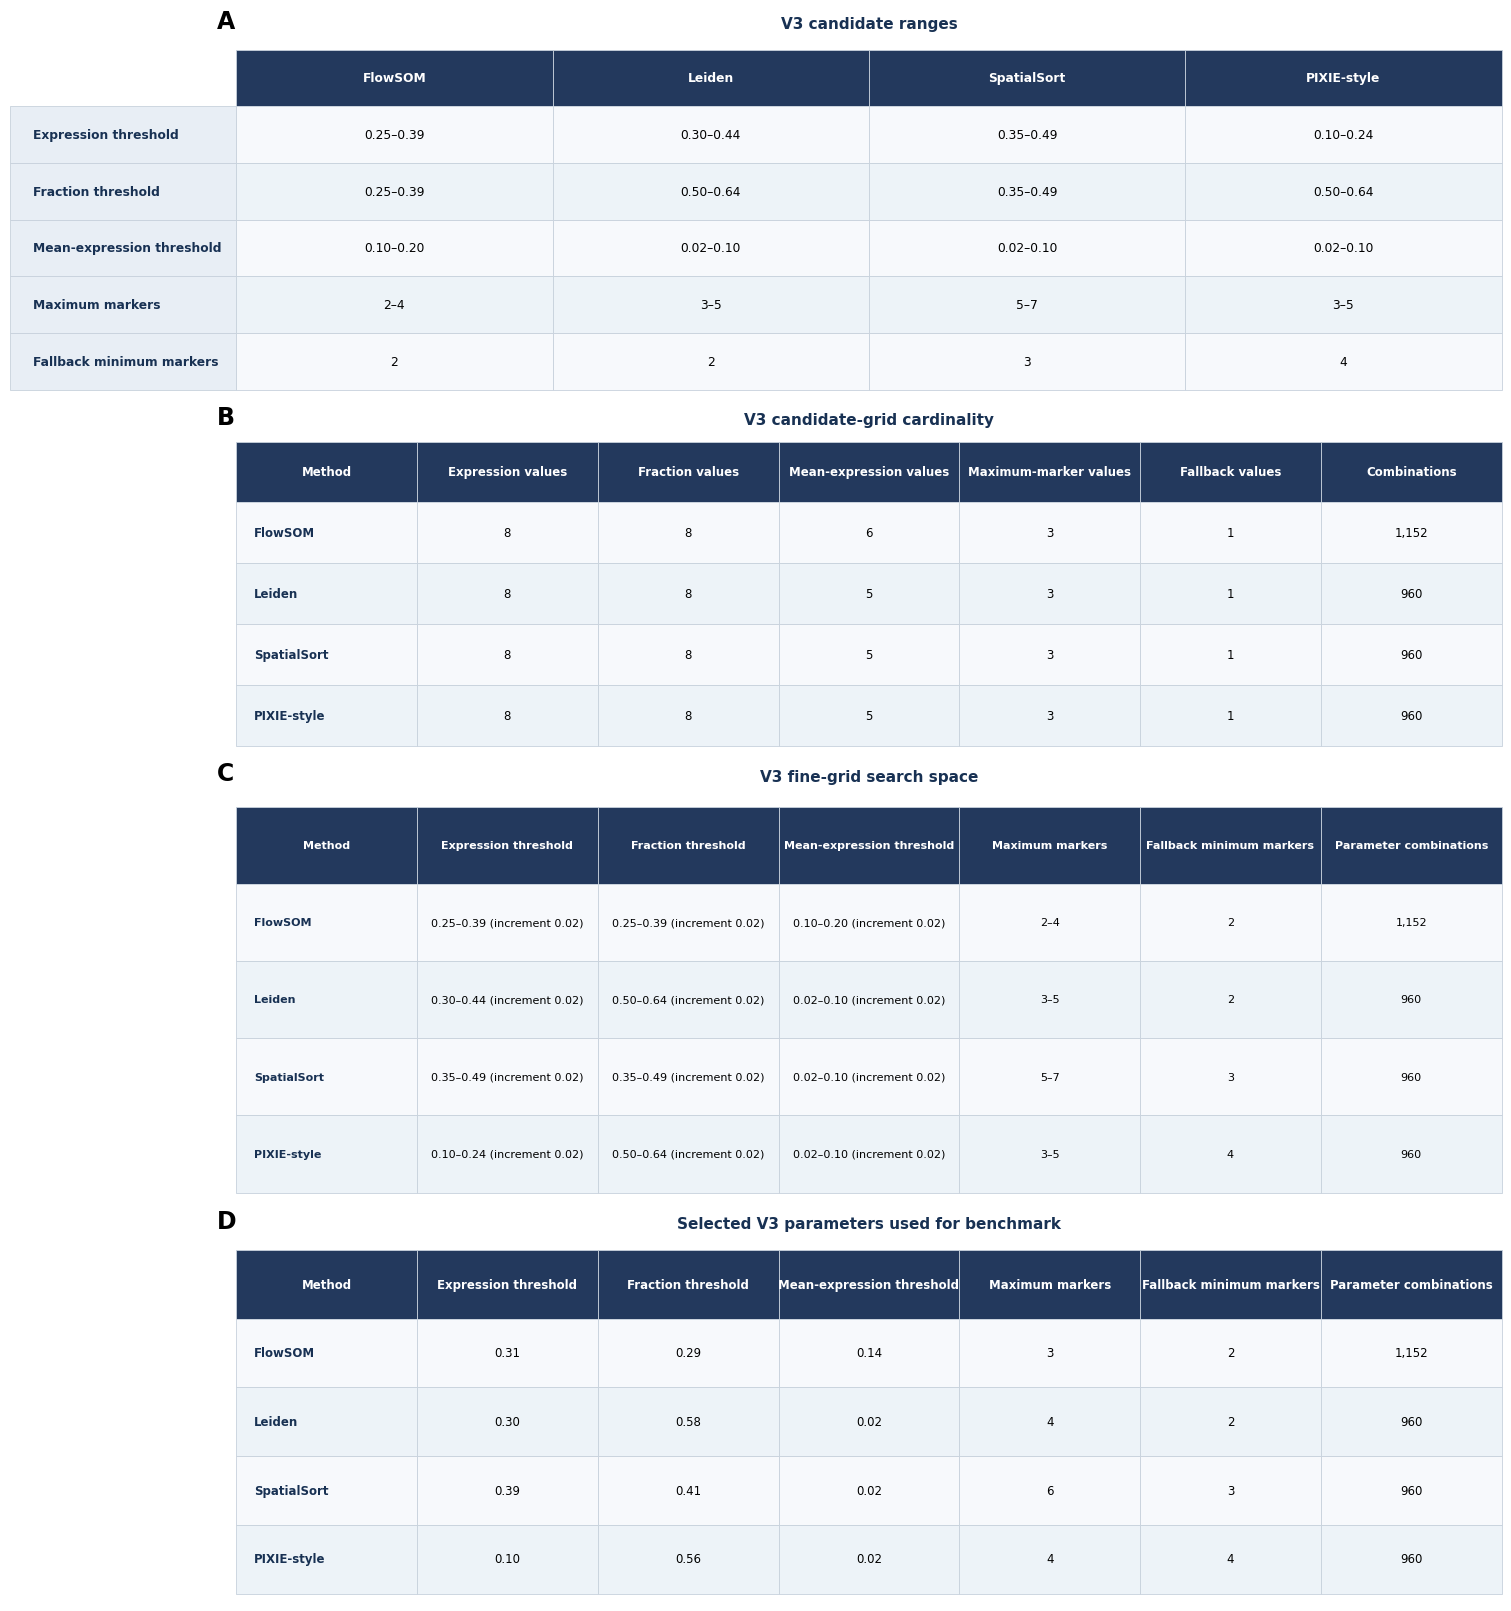

Wrote outputs/source_rebuilt/table_s02/table_s02_marker_summary_optimization.png
Wrote outputs/source_rebuilt/table_s02/table_s02_marker_summary_optimization.pdf


In [3]:
display_names = {
    "FlowSOM": "FlowSOM",
    "Leiden": "Leiden",
    "SpatialSort": "SpatialSort",
    "PIXIE-style adaptation": "PIXIE-style",
}
parameter_labels = {
    "Fine-grid expression threshold": "Expression threshold",
    "Fine-grid fraction threshold": "Fraction threshold",
    "Fine-grid mean-expression threshold": "Mean-expression threshold",
    "Fine-grid maximum markers": "Maximum markers",
    "Fine-grid fallback minimum markers": "Fallback minimum markers",
}

panel_a = (
    source.set_index("Method")[list(parameter_labels)]
    .rename(index=display_names, columns=parameter_labels)
    .T
)
panel_a = panel_a.apply(lambda column: column.str.replace(" (increment 0.02)", "", regex=False))

panel_b = validation_summary.drop(columns=["Selected values on grid"]).copy()
panel_b["Method"] = panel_b["Method"].map(display_names)
panel_b["Combinations"] = panel_b["Combinations"].map(lambda value: f"{value:,}")

panel_c = source[["Method", *grid_columns.values(), "Fine-grid maximum markers", "Fine-grid fallback minimum markers"]].copy()
panel_c["Method"] = panel_c["Method"].map(display_names)
panel_c["Parameter combinations"] = [
    f"{EXPECTED_COMBINATIONS[method]:,}" for method in EXPECTED_METHODS
]
panel_c.columns = [
    "Method",
    "Expression threshold",
    "Fraction threshold",
    "Mean-expression threshold",
    "Maximum markers",
    "Fallback minimum markers",
    "Parameter combinations",
]

panel_d = source[["Method", *selected_columns.values(), "Selected maximum markers", "Selected fallback minimum markers"]].copy()
panel_d["Method"] = panel_d["Method"].map(display_names)
panel_d["Parameter combinations"] = [
    f"{EXPECTED_COMBINATIONS[method]:,}" for method in EXPECTED_METHODS
]
panel_d.columns = [
    "Method",
    "Expression threshold",
    "Fraction threshold",
    "Mean-expression threshold",
    "Maximum markers",
    "Fallback minimum markers",
    "Parameter combinations",
]


def draw_table_panel(axis, data, panel_letter, title, *, font_size=8.5, scale_y=1.75):
    axis.axis("off")
    axis.text(
        -0.015, 1.06, panel_letter, transform=axis.transAxes,
        fontsize=17, fontweight="bold", va="top", ha="left"
    )
    axis.text(
        0.5, 1.04, title, transform=axis.transAxes,
        fontsize=11, fontweight="bold", va="top", ha="center", color="#183153"
    )
    table = axis.table(
        cellText=data.values,
        rowLabels=data.index if not isinstance(data.index, pd.RangeIndex) else None,
        colLabels=data.columns,
        cellLoc="center",
        rowLoc="left",
        loc="upper center",
        bbox=[0, 0.02, 1, 0.93],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1, scale_y)
    for (row, column), cell in table.get_celld().items():
        cell.set_edgecolor("#c7d1dc")
        cell.set_linewidth(0.6)
        if row == 0:
            cell.set_facecolor("#23395d")
            cell.set_text_props(color="white", fontweight="bold")
        elif column == -1:
            cell.set_facecolor("#e8eef5")
            cell.set_text_props(fontweight="bold", ha="left", color="#183153")
        else:
            cell.set_facecolor("#f7f9fc" if row % 2 else "#edf3f8")
            if column == 0 and isinstance(data.index, pd.RangeIndex):
                cell.set_text_props(fontweight="bold", ha="left", color="#183153")
    return table


figure = plt.figure(figsize=(15, 16), constrained_layout=True)
grid = figure.add_gridspec(4, 1, height_ratios=[1.04, 0.93, 1.18, 1.05])
axes = [figure.add_subplot(grid[index, 0]) for index in range(4)]

draw_table_panel(axes[0], panel_a, "A", "V3 candidate ranges", font_size=8.8)
draw_table_panel(axes[1], panel_b, "B", "V3 candidate-grid cardinality", font_size=8.5)
draw_table_panel(axes[2], panel_c, "C", "V3 fine-grid search space", font_size=8.0)
draw_table_panel(axes[3], panel_d, "D", "Selected V3 parameters used for benchmark", font_size=8.5)

png_path = OUTPUT_DIR / "table_s02_marker_summary_optimization.png"
pdf_path = OUTPUT_DIR / "table_s02_marker_summary_optimization.pdf"
figure.savefig(png_path, dpi=220, bbox_inches="tight", facecolor="white")
figure.savefig(pdf_path, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Wrote {png_path.relative_to(REPOSITORY_ROOT)}")
print(f"Wrote {pdf_path.relative_to(REPOSITORY_ROOT)}")

## Interpretation

The fine-grid search evaluated **1,152** parameter combinations for FlowSOM and **960** for each of Leiden, SpatialSort, and the PIXIE-style adaptation. Every selected value lies on its method's declared grid. These counts and selections are derived from the hash-verified source CSV above; they are not manually entered display values.